In [75]:
import pandas as pd
import numpy as np
import re
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter
import ftfy
import emoji
from textblob import TextBlob
import torch

In [76]:
# dataset
data1 = pd.read_csv("../data/Raw_data_1.csv")
data2 = pd.read_csv("../data/Raw_data_2.csv")

In [77]:
data1.head()

,Sentiments,Reviews
0,negative,Stuff and design was totally changed. cheap qu...
1,positive,"i got my parxel before time,sorry for late rev..."
2,positive,So far so good..... Bought it only because it ...
3,neutral,Received as described but not suitable such ha...
4,positive,Received on time and in a safely packed box. T...


In [78]:
data2.head()

,Unnamed: 0,Product_ID,Customer_Name,Customer_ID,Date,Rating,Spam(1) and Not Spam(0),Reviews,Sentiments,Features
0,0,TE111EL1KXNGWNAFAMZ,itzmr7,6702,11/9/2019,1,0,mil gya hai acha hai aur toota howa b nai hai,Positive,['toota']
1,1,MI543EL02ACXSNAFAMZ,Afridi,396,11/21/2016,5,0,aram sy pocket may aa jta hai aur quality b ac...,Positive,"['aram', 'pocket', 'quality']"
2,2,MI543EL02ACXSNAFAMZ,Muhammed,3710,10/22/2018,2,0,sb sy achi chez apki customer service bhot ach...,Positive,"['customer', 'products', 'orignal']"
3,3,TE111EL1KXNGWNAFAMZ,Ghazanfar,1860,10/6/2017,3,0,back cover acha hai sai cuts hai aur soft b ha...,Positive,"['back', 'cover', 'cuts', 'soft', 'protector',..."
4,4,SO638EL103OUWNAFAMZ,Murtaza iqbal,3778,8/31/2017,4,0,shru may may thumb grip k khalif thi kyu k ext...,Negative,"['thumb', 'grip', 'chezy', 'stock', 'controlle..."


In [79]:
# TEXT CLEANING FUNCTION
slang_dict = {
    "osm": "awesome",
    "n": "and",
    "thnkuu": "thank you",
    "thnku": "thank you",
    "soo": "so",
    "parxel": "parcel"
}

def clean_text(text):
    text = str(text).lower()

    text = ftfy.fix_text(text) # fix the broken text caused by encoding problems (CafÃ© -> Cafe)
    text = emoji.demojize(text) # convert emojis to text (:) to :smiling_face:)

    text = re.sub(r':\w+:', ' ', text) # now remove emoji labels like :smiling_face:
    text = re.sub(r'http\S+|www\S+', '', text) # remove URLS
    text = re.sub(r'[^a-zA-Z\s]', ' ', text) # remove special characters
    text = re.sub(r'(.)\1{2,}', r'\1', text)  # fix repeated letters (soo → so, goood → god)

    for k, v in slang_dict.items(): # slang replacement
        text = re.sub(r'\b' + k + r'\b', v, text)

    text = re.sub(r'\s+', ' ', text).strip() # remove extra spaces

    return text


In [80]:
# URDU MIXING RATIO FUNCTION - calculates percentage of Roman Urdu words in a sentence.

urdu_words = [
    'hai','ka','ki','ke','mein','se','ko','nahi','aur','yeh','kya',
    'hum','tum','tha','thi','hy','nhi','bhi','jo','ye','wo','ap',
    'hain','koi','bahut','bohat','achha','acha','bura','yaar','bhai'
]

def mixing_ratio(text):
    words = str(text).lower().split()
    if len(words) == 0:
        return 0
    urdu_count = sum(1 for w in words if w in urdu_words) # How many words in the sentence are in the Urdu list?
    return urdu_count / len(words)

In [ ]:
label_map = {'positive': 2, 'neutral': 1, 'negative': 0}

def process_dataset(df, text_col='Reviews', label_col='Sentiments'):
    
    df = df.copy()

    # clean text
    df['Clean_Reviews'] = df[text_col].apply(clean_text)
    # label encoding
    df['Sentiment_label'] = df[label_col].str.lower().map(label_map)
    # EDA features 
    df['Review_length'] = df['Clean_Reviews'].apply(lambda x: len(str(x).split()))
    df['urdu_ratio'] = df[text_col].apply(mixing_ratio)

    # final ML dataset (ONLY 2 columns)
    final_df = df[['Clean_Reviews', 'Sentiment_label']]

    return df, final_df

In [91]:
def sentiment_distribution_eda(df, sentiment_col='Sentiments', plot=True):

    sent_counts = df[sentiment_col].value_counts()

    if plot:
        sent_counts.plot(kind='bar', color=['#4CAF50', '#FF5252', '#FFC107'])
        plt.title("Sentiment Distribution")
        plt.xlabel("Sentiments")
        plt.ylabel("Count")
        plt.xticks(rotation=0)
        plt.grid(axis='y', linestyle='--', alpha=0.4)
        plt.tight_layout()
        plt.show()

    return sent_counts

In [103]:
def review_length_analysis(df,Data, sentiment_col='Sentiments', text_col='Clean_Reviews', plot=True):

    df = df.copy()
    df['Review_length'] = df[text_col].apply(lambda x: len(str(x).split()))

    stats = df.groupby(sentiment_col)['Review_length'].describe()

    if plot:
        plt.figure(figsize=(7,5))
        sns.boxplot(x=sentiment_col, y='Review_length', data=df)
        plt.title(f"Review Length by Sentiment Data: {Data}")
        plt.show()

    return df, stats

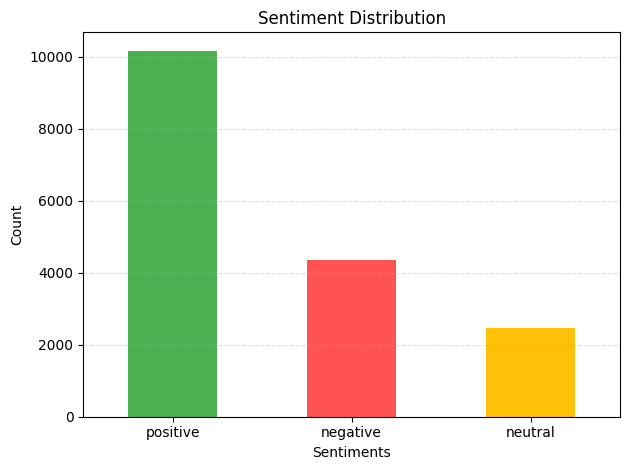

Sentiments
positive    10167
negative     4362
neutral      2461
Name: count, dtype: int64

In [84]:
sent_counts1 = sentiment_distribution_eda(data1)
sent_counts1

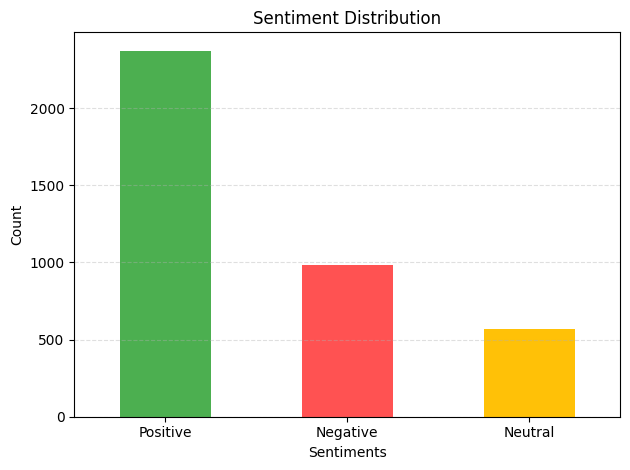

Sentiments
Positive    2372
Negative     983
Neutral      568
Name: count, dtype: int64

In [92]:
sent_counts1 = sentiment_distribution_eda(data2)
sent_counts1

In [93]:
data1_full, data1_final = process_dataset(data1)
data2_full, data2_final = process_dataset(data2)

In [96]:
data1_final

,Clean_Reviews,Sentiment_label
0,stuff and design was totally changed cheap qua...,0
1,i got my parcel before time sorry for late rev...,2
2,so far so good bought it only because it has t...,2
3,received as described but not suitable such ha...,1
4,received on time and in a safely packed box th...,2
...,...,...
16985,it is doing nothing i have wasted my money and...,0
16986,bht he achi prdct h jo cheez dekhi whi mili ma...,2
16987,product quality is not very good but working o...,1
16988,very soft and cozy product perfect travel part...,2


In [95]:
data2_final

,Clean_Reviews,Sentiment_label
0,mil gya hai acha hai aur toota howa b nai hai,2
1,aram sy pocket may aa jta hai aur quality b ac...,2
2,sb sy achi chez apki customer service bhot ach...,2
3,back cover acha hai sai cuts hai aur soft b ha...,2
4,shru may may thumb grip k khalif thi kyu k ext...,0
...,...,...
3918,tasweer isi terhan tha jaisay tasweer aur tars...,2
3919,waqt par masool hwa aaccha lagta hai mein iss ...,1
3920,masnoaat isi terhan ki thi jaisay website par ...,2
3921,mein nai iss ac ko hbl shop festa se khareeda ...,0


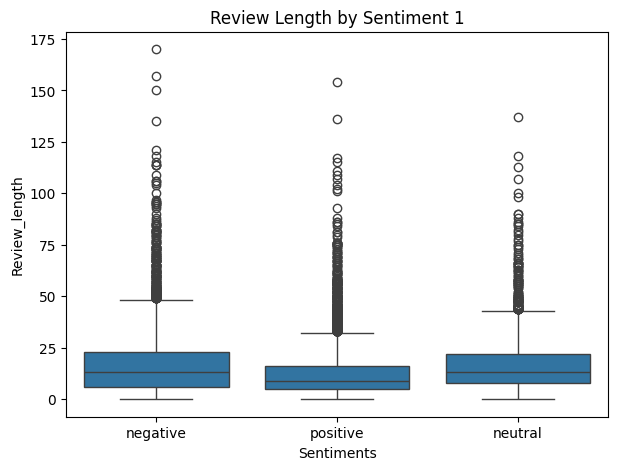

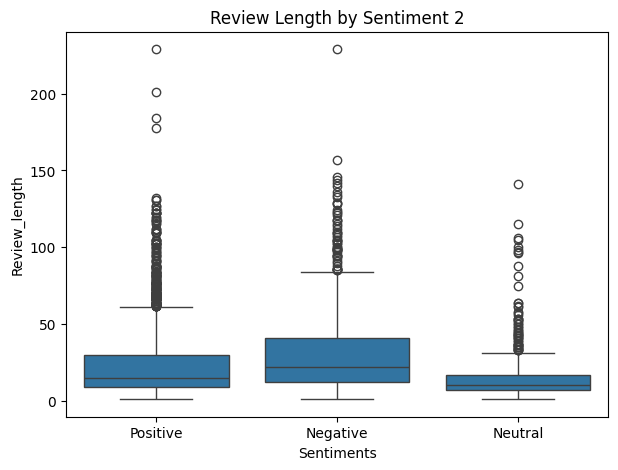

In [102]:
data1_full, stats1 = review_length_analysis(data1_full, 1)
data2_full, stats2 = review_length_analysis(data2_full, 2)

In [104]:
final_data = pd.concat([data1_final, data2_final], ignore_index=True)

final_data.to_csv("../data/FINAL_DATA.csv", index=False)